#Image garbage classification

This analysis is based upon images (very small dataset) within the "img" folder in the datasets folder. Link below.

https://github.com/MEMAUDATA/memaudata.github.io/blob/main/datasets/img

Task : To classify, from an image, whether a trash garbage is clean or dirty.

1. Create a manual neural network for this classification task
2. Create a CNN using Pytorch
3. Creata a CNN using Tensorflow

First step EDA to analyse the image in the train folder!

Example images :

Clean img : RGB , size : 803, 600, 3 ! Grayscale seems ok ! Dirty img : RGB , size : 141, 250, 3 ! Grayscale seems ok !

=> Need to control the size of each image ?!

Nb of images in test folder : 38 Nb of images in training folder : 99

=> Training images size are not normally distributed (mean ≠ median). => Bimodel distribution with two peaks : a small around 150 and a big sharp one arounf 255 ! True for both type og images.

# Exploratory Data Analysis

### Install all required librairies from requirements.txt

In [237]:
#!pip install -r requirements.txt 

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as T
from PIL import Image, ImageFilter
from tqdm import tqdm
from tqdm.keras import TqdmCallback
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [239]:
# From Jupyter to pdf
import nbconvert
# In the Terminal
# jupyter nbconvert --to html garbage.ipynb

# Display the two example img for better visualisation

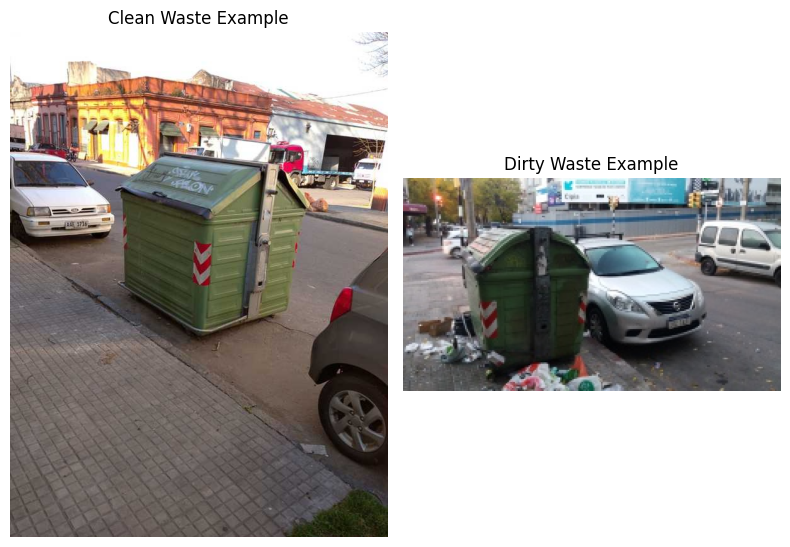

In [240]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 8))

clean = Image.open('./datasets/img/clean.jpeg')
dirty = Image.open('./datasets/img/dirty.jpeg')

axes[0].imshow(clean)
axes[1].imshow(dirty)

axes[0].set_title("Clean Waste Example")
axes[1].set_title("Dirty Waste Example")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [241]:
clean = np.array(clean)
dirty = np.array(dirty)
print(f"Clean shape : {clean.shape}")
print(f"Dirty shape : {dirty.shape}")

Clean shape : (803, 600, 3)
Dirty shape : (141, 250, 3)


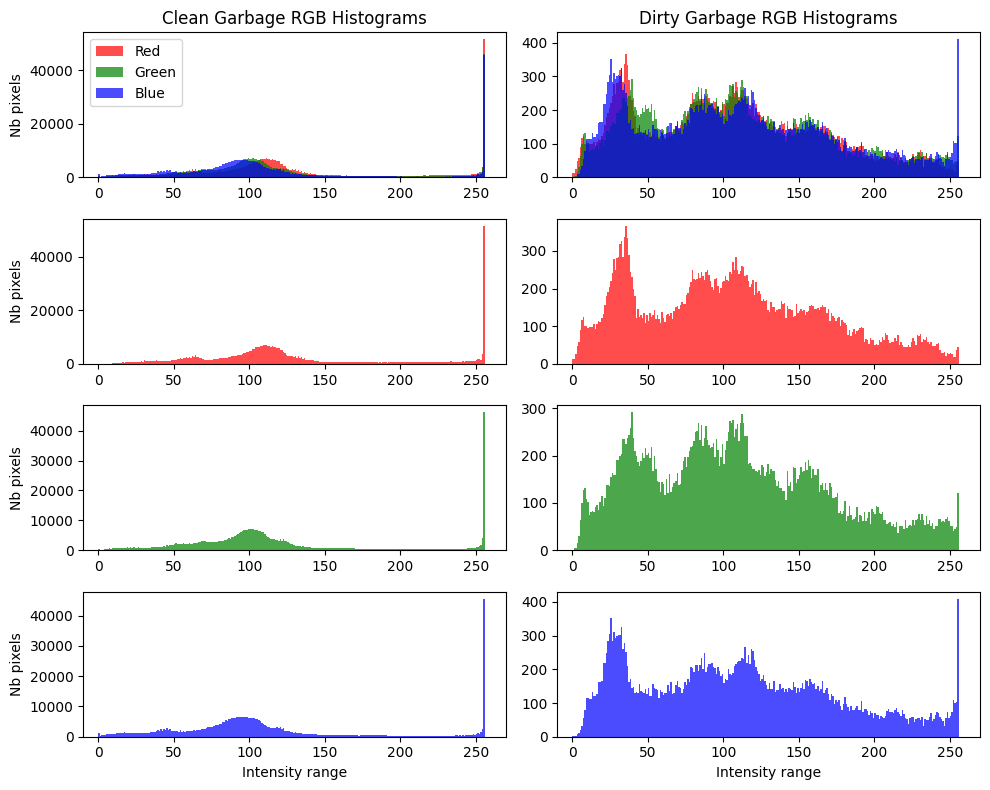

In [242]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 8)) 
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
        axes[0,0].hist(clean[:, :, i].flatten(), bins=256, range=[0, 256], color=color, alpha=0.7, label=color.capitalize())
        axes[0,1].hist(dirty[:, :, i].flatten(), bins=256, range=[0, 256], color=color ,alpha=0.7)
        axes[i+1,0].hist(clean[:, :, i].flatten(), bins=256, range=[0, 256], color=color ,alpha=0.7)
        axes[i+1,1].hist(dirty[:, :, i].flatten(), bins=256, range=[0, 256], color=color ,alpha=0.7)
        axes[i,0].set_ylabel("Nb pixels")
        axes[0,0].set_xlim([-10, 270])
        axes[0,1].set_xlim([-10, 270])
        axes[i+1,0].set_xlim([-10, 270])
        axes[i+1,1].set_xlim([-10, 270])

axes[3,0].set_ylabel("Nb pixels")
axes[0,0].set_title("Clean Garbage RGB Histograms")
axes[0,1].set_title("Dirty Garbage RGB Histograms")
axes[3,0].set_xlabel("Intensity range")
axes[3,1].set_xlabel("Intensity range")
axes[0,0].legend()


plt.tight_layout()
plt.show()


Clean shape : (803, 600)
Dirty shape : (141, 250)


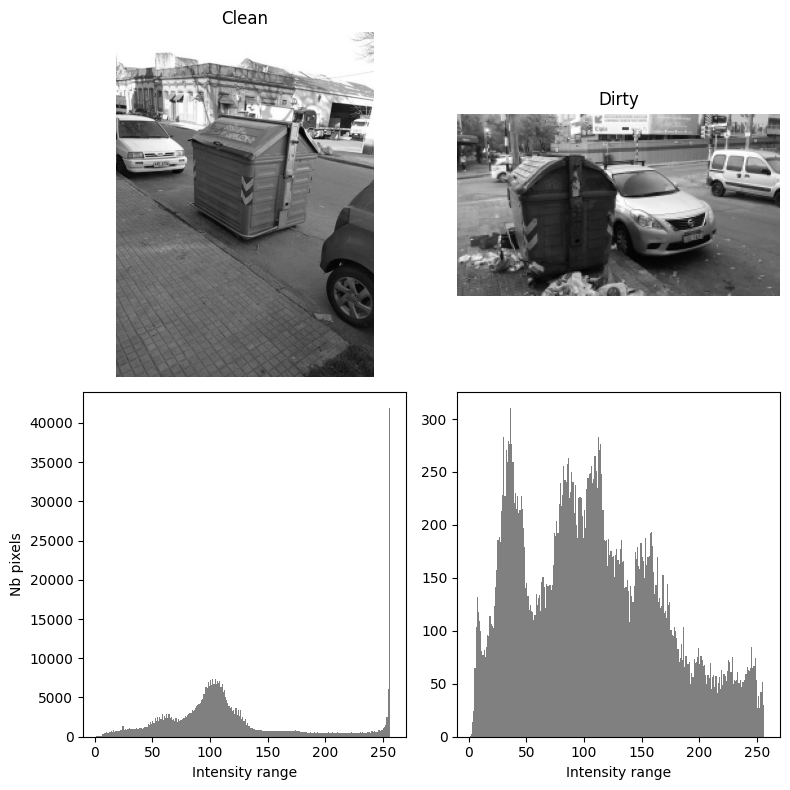

In [243]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8)) 
clean = Image.open('./datasets/img/clean.jpeg').convert('L')
dirty = Image.open('./datasets/img/dirty.jpeg').convert('L')
clean = np.array(clean)
dirty = np.array(dirty)

print(f"Clean shape : {clean.shape}")
print(f"Dirty shape : {dirty.shape}")

axes[0,0].imshow(clean,cmap='gray')
axes[0,1].imshow(dirty,cmap='gray')

axes[0,0].set_title("Clean")
axes[0,1].set_title("Dirty")
axes[0,0].axis("off")
axes[0,1].axis("off") 

axes[1,0].hist(clean.flatten(), bins=256, range=[0, 256], color='gray')
axes[1,1].hist(dirty.flatten(), bins=256, range=[0, 256], color='gray')


axes[1,0].set_ylabel("Nb pixels")
axes[1,0].set_xlabel("Intensity range")
axes[1,1].set_xlabel("Intensity range")

axes[1,0].set_xlim([-10, 270])
axes[1,1].set_xlim([-10, 270])


plt.tight_layout()
plt.show()

Based upon the two example images, the size and the histogram of each image are totally different ! 

# Count number of images within each folder (test and train) and analyse the train images.

In [244]:
BASE_DIR = os.getcwd()  # notebook directory
train_clean_dir = os.path.join(BASE_DIR, 'datasets', 'img', 'train', 'clean')
train_dirty_dir = os.path.join(BASE_DIR, 'datasets', 'img', 'train', 'dirty')

# Count the nb of img within test and training folders

In [245]:
def count_image_files(directory):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    return sum(1 for f in os.listdir(directory) if f.lower().endswith(exts))


clean_count = count_image_files(train_clean_dir)
dirty_count = count_image_files(train_dirty_dir)

print(f"nb img training/clean folder : {clean_count}")
print(f"nb img training/dirty folder : {dirty_count}")
print(f"nb img total training folder : {clean_count + dirty_count}")



nb img training/clean folder : 56
nb img training/dirty folder : 44
nb img total training folder : 100


# Display all training imgs and compute average size

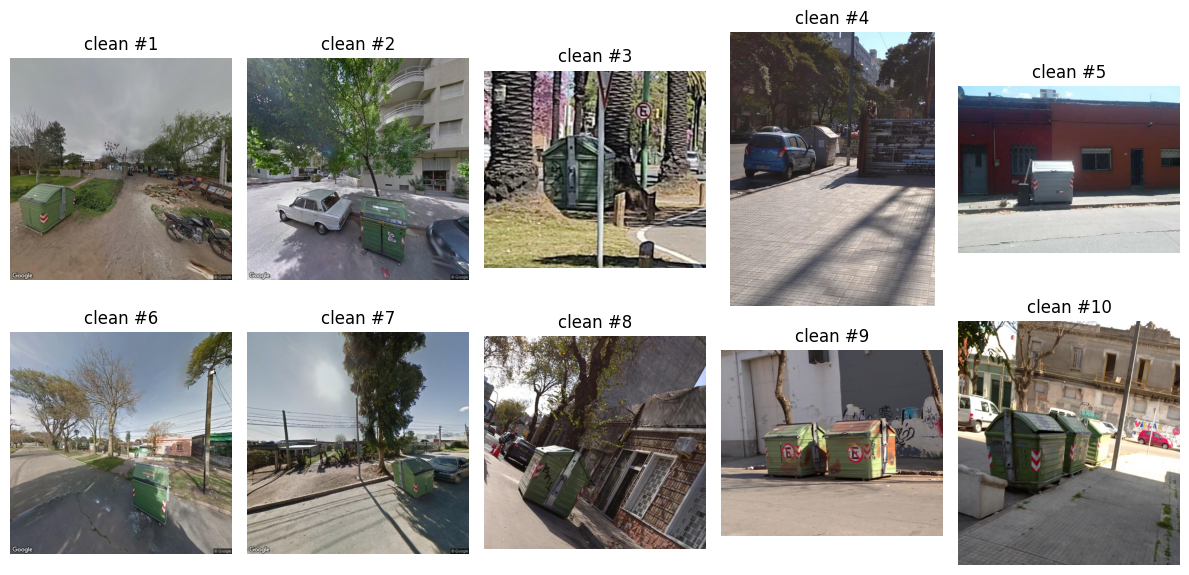

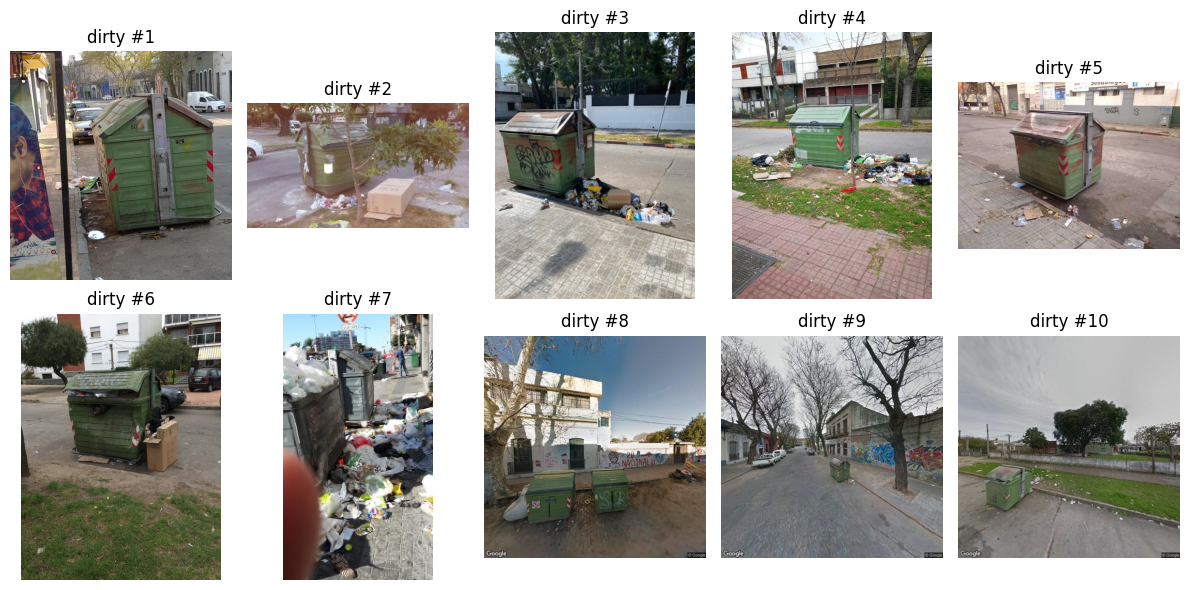

In [246]:
# Get a list of image filenames
clean_img = [f for f in os.listdir(train_clean_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
dirty_img = [f for f in os.listdir(train_dirty_dir) if f.lower().endswith(('.jpg', '.jpeg'))]

# Create 2 subplots : clean and dirty

def display_img(img_list, folder_path, img_title, img_2_display=10):
    img_2_display = min(img_2_display, len(img_list))
    rows = (img_2_display + 4) // 5

    fig, axes = plt.subplots(nrows=rows, ncols=5, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(img_2_display):
        img_path = os.path.join(folder_path, img_list[i])
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"{img_title} #{i+1}")

    # Hide unused axes
    for j in range(img_2_display, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


display_img(clean_img,train_clean_dir,"clean")
display_img(dirty_img,train_dirty_dir,"dirty")

# Compute basic stats on each img folder

In [247]:
def cnt_shape_img(img_list,folder_path):

    img_size = []

    for i in range(len(img_list)):
        filename = img_list[i]
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path)
        img = np.array(img)
        img_size.append(img.shape)

    return  pd.DataFrame(img_size, columns=["X", "Y", "Z"])

c = cnt_shape_img(clean_img,train_clean_dir)
d = cnt_shape_img(dirty_img,train_dirty_dir)
df = pd.concat([c, d])

# Dirty data image size
print(f"Clean :\n{c.agg(['median','mean', 'std', 'min', 'max'])}\n" )
print(f"Dirty :\n{d.agg(['median','mean', 'std', 'min','max'])}\n" )
print(f"All :\n{df.agg(['median','mean', 'std', 'min','max'])}\n" )    

Clean :
                  X            Y         Z
median   600.000000   600.000000  3.000000
mean     877.589286   849.125000  3.017857
std      494.094315   499.838049  0.133631
min      244.000000   187.000000  3.000000
max     2448.000000  3264.000000  4.000000

Dirty :
                  X            Y    Z
median   774.000000   600.000000  3.0
mean    1071.681818  1086.136364  3.0
std     1037.061227   988.328201  0.0
min      141.000000   140.000000  3.0
max     4160.000000  4160.000000  3.0

All :
                 X            Y     Z
median   652.00000   600.000000  3.00
mean     962.99000   953.410000  3.01
std      782.39253   759.633844  0.10
min      141.00000   140.000000  3.00
max     4160.00000  4160.000000  4.00



# Detect corrupted img

In [248]:
from PIL import Image, UnidentifiedImageError
import os

def find_corrupted(image_paths):
    corrupted = []

    for path in image_paths:
        try:
            # Try opening the file
            with Image.open(path) as img:
                img.verify()  # Check file integrity

            # Re-open to ensure it can be fully loaded
            with Image.open(path) as img:
                img.load()

        except (OSError, UnidentifiedImageError, ValueError):
            corrupted.append(path)

    return corrupted


In [249]:
corrupted_clean          = find_corrupted(clean_img)
corrupted_dirty          = find_corrupted(dirty_img)
print("Corrupted clean images:", len(corrupted_clean))
print("Corrupted dirty images:", len(dirty_img))


Corrupted clean images: 56
Corrupted dirty images: 44


# Preprocessing

In [250]:
clean_paths = [os.path.join(train_clean_dir, f) for f in os.listdir(train_clean_dir)] 
dirty_paths = [os.path.join(train_dirty_dir, f) for f in os.listdir(train_dirty_dir)] 
all_images = clean_paths + dirty_paths 
all_labels = [1]*len(clean_paths) + [0]*len(dirty_paths)

## Split train and test images based upon paths

In [251]:
X_train_paths, X_test_paths, y_train, y_test = train_test_split(all_images, all_labels, test_size=0.2, shuffle=True, random_state=0 )

## Preprocess images (resize/normalize/flatten) for artificial neuron

In [252]:
def preprocessing_image(image_path, target_size=(32,32), grayscale=True, flat=True):

    # Skip non-image files such as .DS_Store
    if not image_path.lower().endswith(('.jpg', '.jpeg', '.png')):
        return None

    try:
        img = Image.open(image_path).convert('L' if grayscale else 'RGB')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        img_array = np.array(img).astype(np.float32) / 255.0

        if flat:
            img_array = img_array.flatten()

        return img_array

    except Exception as e:
        print("Skipping:", image_path, "->", e)
        return None

# Remove files that are not images (desired extension)
valid_exts      = ('.jpg', '.jpeg', '.png')
train_pairs = list(zip(X_train_paths, y_train))
test_pairs = list(zip(X_test_paths, y_test))
train_pairs = [(path, label) for path, label in train_pairs if path.lower().endswith(valid_exts)]
test_pairs  = [(path, label) for path, label in test_pairs if path.lower().endswith(valid_exts)]


X_train_an  = []
y_train_an  = []
X_test_an   = []
y_test_an   = []

for path, label in train_pairs:
    arr = preprocessing_image(path)
    if arr is not None:
        X_train_an.append(arr)
        y_train_an.append(label)

for path, label in test_pairs:
    arr = preprocessing_image(path)
    if arr is not None:
        X_test_an.append(arr)
        y_test_an.append(label)

# Convert to arrays
X_train_an = np.array(X_train_an)
X_test_an  = np.array(X_test_an)

y_train_an = np.array(y_train_an).reshape(-1, 1)
y_test_an  = np.array(y_test_an).reshape(-1, 1)

# print vertically for smoother reading
print(X_train_an.shape)
print(X_test_an.shape)
print(y_train_an.shape)
print(y_test_an.shape) 

(80, 1024)
(20, 1024)
(80, 1)
(20, 1)


# Neural network for classification

In [253]:
class artificial_neuron:
    """Artificial neuron (logistic regression)"""

    def __init__(self, n_iter=100, learning_rate=0.1, penalty='l2', alpha=0.01):
        self.coef_ = None
        self.bias_ = None
        self.n_iter_ = n_iter
        self.learning_rate_ = learning_rate
        self.loss_ = []
        self.accuracy_ = []
        self.test_accuracy_ = []
        self.penalty = penalty
        self.alpha = alpha

    def predict_proba(self, X):
        Z = X.dot(self.coef_) + self.bias_
        Z = np.clip(Z, -800, 800)
        return 1 / (1 + np.exp(-Z))

    def log_loss(self, y, A):
        eps = 1e-15
        return np.mean(-y * np.log(A + eps) - (1 - y) * np.log(1 - A + eps))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def evaluate(self, X, y):
        return np.mean(self.predict(X) == y)

    def display_loss_acc(self):
        fig, axes = plt.subplots(1, 2, figsize=(10, 6))
        axes[0].plot(self.loss_, label='Loss')
        axes[1].plot(self.accuracy_, label='Training Accuracy', color='orange')
        axes[1].plot(self.test_accuracy_, label=f'Test Accuracy: {self.test_accuracy_[-1]:.2f}', color='green')
        axes[0].set_xlabel('Iterations')
        axes[1].set_xlabel('Iterations')
        axes[0].legend()
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    def fit(self, X, y, X_test, y_test):

        # Initialisation
        self.coef_ = np.random.randn(X.shape[1], 1) * 0.01
        self.bias_ = 0.0

        for _ in tqdm(range(self.n_iter_)):

            # Forward
            A = self.predict_proba(X)

            # Loss
            self.loss_.append(self.log_loss(y, A))

            # Accuracy
            self.accuracy_.append(self.evaluate(X, y))
            self.test_accuracy_.append(self.evaluate(X_test, y_test))

            # Gradients
            dW = (1 / len(y)) * X.T.dot(A - y)
            db = (1 / len(y)) * np.sum(A - y)

            # Regularization
            if self.penalty == 'l2':
                dW += self.alpha * self.coef_
            elif self.penalty == 'l1':
                dW += self.alpha * np.sign(self.coef_)

            # Update
            self.coef_ -= self.learning_rate_ * dW
            self.bias_ -= self.learning_rate_ * db

        return self    


100%|██████████| 100/100 [00:00<00:00, 1233.73it/s]


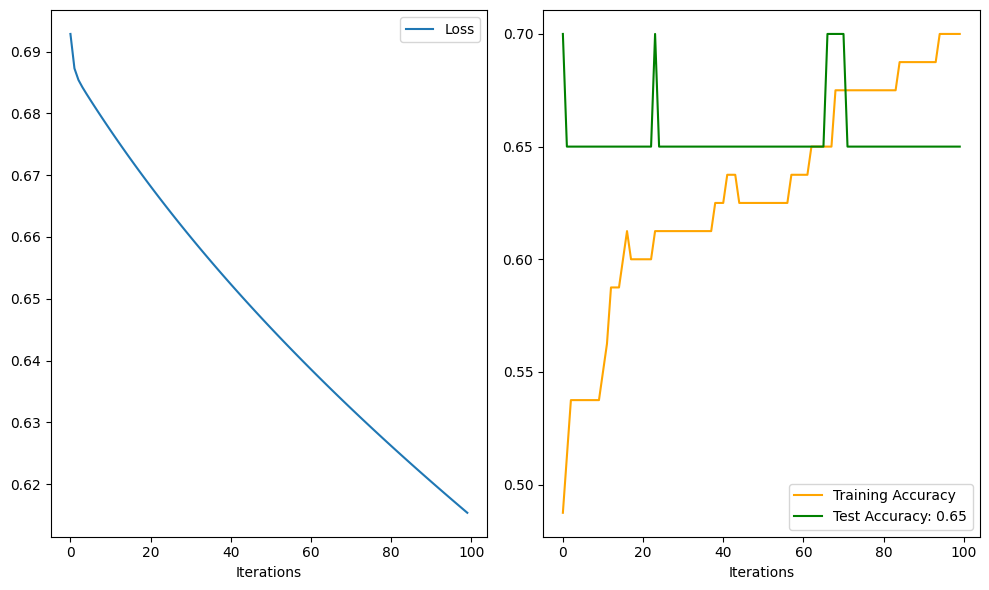

In [254]:
model = artificial_neuron(n_iter= 100,learning_rate = 0.01,penalty ='l2', alpha=0.001)
model.fit(X_train_an, y_train_an,X_test_an,y_test_an)
model.display_loss_acc()

100%|██████████| 1000/1000 [00:00<00:00, 1673.23it/s]


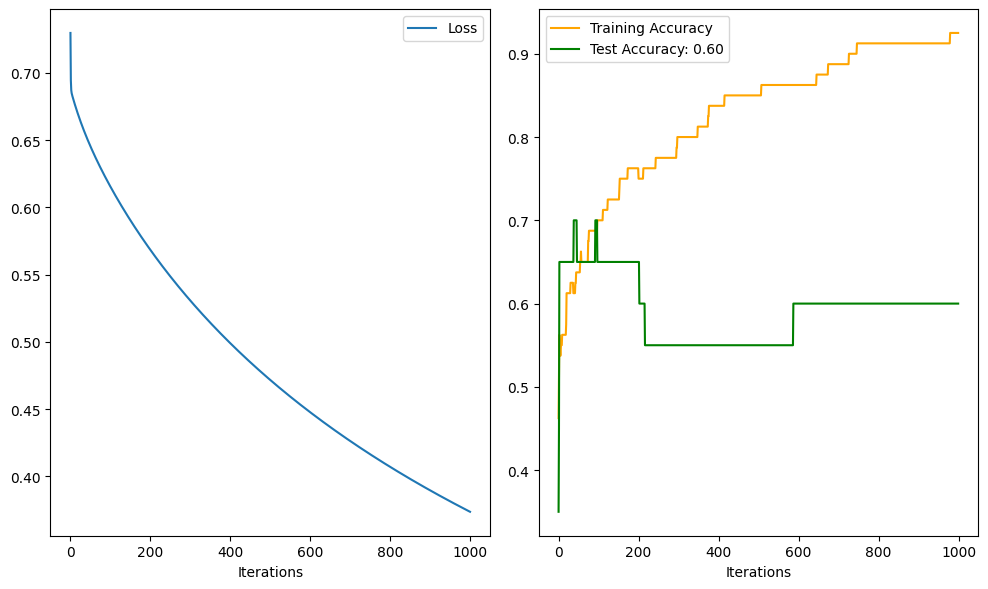

In [255]:
model = artificial_neuron(n_iter= 1000,learning_rate = 0.01,penalty ='l2', alpha=0.001)
model.fit(X_train_an, y_train_an,X_test_an,y_test_an)
model.display_loss_acc()

100%|██████████| 10000/10000 [00:05<00:00, 1786.95it/s]


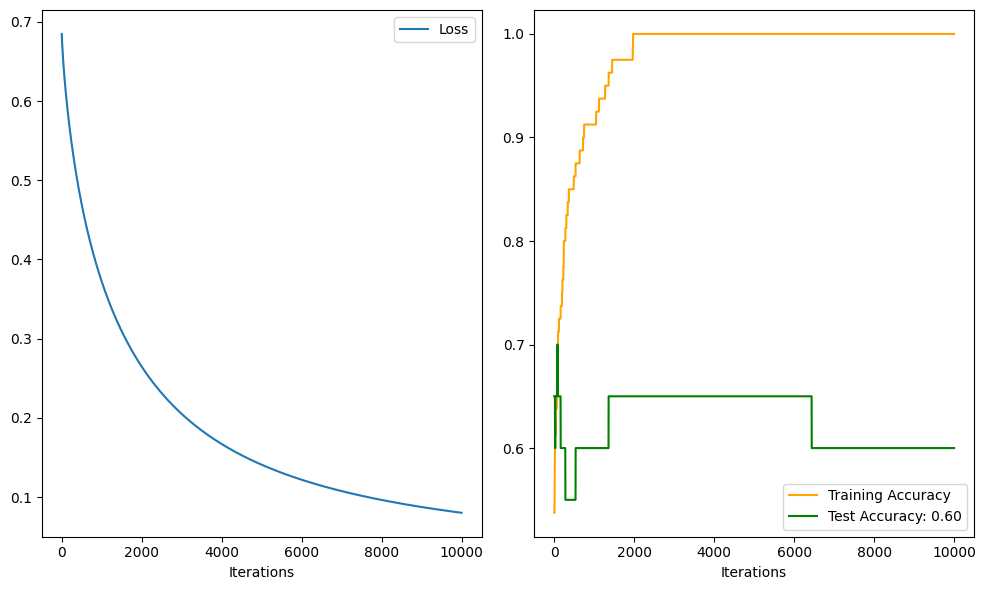

In [256]:
model = artificial_neuron(n_iter= 10000,learning_rate = 0.01,penalty ='l2', alpha=0.001)
model.fit(X_train_an, y_train_an,X_test_an,y_test_an)
model.display_loss_acc()

Conclusion:

The model is not well designed for this kind of data. Need more data ?


# Preprocess images for CNN with Pytorch and Tensorflow

Do not flatten image for PyTorch and TensorFlow to have a (batch_size, channels, height, width) format

In [257]:
def preprocessing_image(image_path, target_size=(32,32), grayscale=True, flat=False):

    # Skip non-image files such as .DS_Store
    if not image_path.lower().endswith(('.jpg', '.jpeg')):
        return None

    try:
        img = Image.open(image_path).convert('L' if grayscale else 'RGB')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        img_array = np.array(img).astype(np.float32) / 255.0

        if flat:
            img_array = img_array.flatten()

        return img_array

    except Exception as e:
        print("Skipping:", image_path, "->", e)
        return None

# Remove files that are not images (desired extension)
valid_exts      = ('.jpg', '.jpeg')
train_pairs = list(zip(X_train_paths, y_train))
test_pairs = list(zip(X_test_paths, y_test))
train_pairs = [(path, label) for path, label in train_pairs if path.lower().endswith(valid_exts)]
test_pairs  = [(path, label) for path, label in test_pairs if path.lower().endswith(valid_exts)]


X_train_cnn  = []
y_train_cnn  = []
X_test_cnn   = []
y_test_cnn   = []

for path, label in train_pairs:
    arr = preprocessing_image(path)
    if arr is not None:
        X_train_cnn.append(arr)
        y_train_cnn.append(label)

for path, label in test_pairs:
    arr = preprocessing_image(path)
    if arr is not None:
        X_test_cnn.append(arr)
        y_test_cnn.append(label)

# Convert to arrays
X_train_cnn = np.stack(X_train_cnn)
X_test_cnn  = np.stack(X_test_cnn)

y_test_cnn = np.array(y_test_cnn).reshape(-1, 1)
y_train_cnn  = np.array(y_train_cnn).reshape(-1, 1)

# print vertically for smoother reading
print(X_train_cnn.shape)
print(X_test_cnn.shape)
print(y_test_cnn.shape)
print(y_train_cnn.shape) 

(80, 32, 32)
(20, 32, 32)
(20, 1)
(80, 1)


Check format : must be N,1,32,32 -> 32 is the img size

In [258]:
if X_train_cnn.shape[1] != 1:
    X_train_cnn = np.expand_dims(X_train_cnn, axis=1)
if X_test_cnn.shape[1] != 1:    
    X_test_cnn = np.expand_dims(X_test_cnn, axis=1)



X_train_tensor          = torch.tensor(X_train_cnn, dtype=torch.float32)
X_test_tensor           = torch.tensor(X_test_cnn, dtype=torch.float32)
y_train_tensor          = torch.tensor(y_train_cnn, dtype=torch.float32)
y_test_tensor           = torch.tensor(y_test_cnn, dtype=torch.float32)


print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


X_train_tensor: torch.Size([80, 1, 32, 32])
y_train_tensor: torch.Size([80, 1])
X_test_tensor: torch.Size([20, 1, 32, 32])
y_test_tensor: torch.Size([20, 1])


In [259]:
# Define data sets
train_dataset           = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset            = TensorDataset(X_test_tensor, y_test_tensor)

# Define data loader
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

for images, labels in train_dataloader:
    print("train_dataloader : ",images.shape, labels.shape)
    break

for images, labels in test_dataloader:
    print("test_dataloader : ",images.shape, labels.shape)
    break


train_dataloader :  torch.Size([16, 1, 32, 32]) torch.Size([16, 1])
test_dataloader :  torch.Size([16, 1, 32, 32]) torch.Size([16, 1])


# CNN using Pytorch

Define the Pytorch model

In [260]:
class GarbageCNN(nn.Module):
    def __init__(self, input_shape):
        super().__init__()

        self.conv1   = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu    = nn.ReLU()
        self.pool    = nn.MaxPool2d(2)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            dummy = self.pool(self.relu(self.conv1(dummy)))
            dummy = self.pool(self.relu(self.conv2(dummy)))
            flat_size = dummy.numel()

        self.fc1     = nn.Linear(flat_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return self.sigmoid(x)


Train and evaluate the model

In [261]:
def train_cnn_model(model, train_dataloader, test_dataloader, criterion, optimizer, num_epochs=100, device="cpu"):

    model.to(device)

    all_loss = []
    train_acc = []
    test_acc = []

    for epoch in tqdm(range(num_epochs)):

        # ----- TRAIN -----
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        all_loss.append(epoch_loss / len(train_dataloader))
        train_acc.append(correct / total)

        # ----- TEST -----
        model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                preds = (outputs > 0.5).float()
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)

        test_acc.append(correct_test / total_test)

    # ----- PLOTS -----
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    axes[0].plot(all_loss, label='Training Loss', color='blue')
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(train_acc, label='Training Accuracy', color='orange')
    axes[1].plot(test_acc, label=f'Test Accuracy (final: {test_acc[-1]:.2f})', color='green')
    axes[1].set_title("Accuracy per Epoch")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    return model, all_loss, train_acc, test_acc


100%|██████████| 40/40 [00:01<00:00, 22.06it/s]


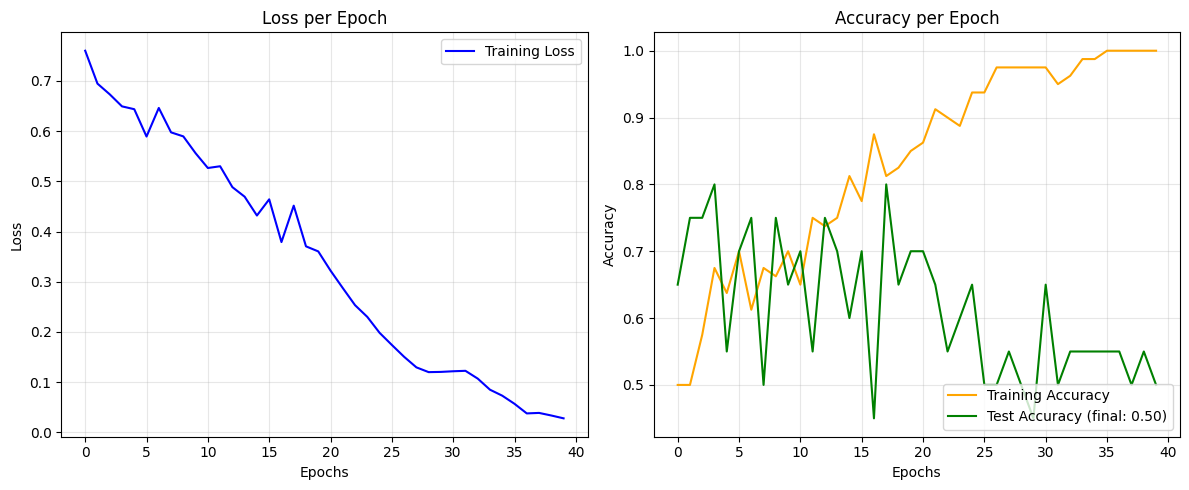

In [262]:
model                                       = GarbageCNN(input_shape=(1, 32, 32))
criterion                                   = nn.BCELoss()
optimizer                                   = optim.Adam(model.parameters(), lr=0.01,weight_decay=1e-3) # weight_decay=1e-3 = L2
model, loss_curve, train_curve, test_curve  = train_cnn_model(model,train_dataloader,test_dataloader,criterion,optimizer,num_epochs=40,device="cpu")

Dataset is too small for a CNN. Try to perform data augmentation

In [276]:
# Check images in the path
valid_exts      = ('.jpg', '.jpeg')
train_pairs     = list(zip(X_train_paths, y_train))
test_pairs      = list(zip(X_test_paths, y_test))
train_pairs     = [(path, label) for path, label in train_pairs if path.lower().endswith(valid_exts)]
test_pairs      = [(path, label) for path, label in test_pairs if path.lower().endswith(valid_exts)]

# Unzip the filtered pairs 
X_train_paths, y_train = zip(*train_pairs) 
X_test_paths, y_test = zip(*test_pairs)

# Transform train and tests images
transform_train = T.Compose([T.RandomHorizontalFlip(),T.RandomRotation(10),T.Resize((32, 32)),T.RandomCrop(32, padding=4),T.ToTensor(),T.Normalize(mean=[0.5], std=[0.5])])
transform_test = T.Compose([T.Resize((32, 32)), T.ToTensor(),T.Normalize(mean=[0.5], std=[0.5])])


class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image_path = self.paths[idx]
        img = Image.open(image_path).convert("L")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([self.labels[idx]], dtype=torch.float32)
        return img, label


augmented_train_dataset = ImageDataset(X_train_paths, y_train, transform=transform_train)
augmented_test_dataset  = ImageDataset(X_test_paths, y_test, transform=transform_test)

Create new dataloader

In [277]:
augmented_train_dataloader = DataLoader(augmented_train_dataset, batch_size=16, shuffle=True, num_workers=0) # num_workers =2 crashes on my computer
augmented_test_dataloader  = DataLoader(augmented_test_dataset, batch_size=16, shuffle=False)

for images, labels in augmented_train_dataloader:
    print("augmented_train_dataloader : ", images.shape, labels.shape)
    break

for images, labels in augmented_test_dataloader:
    print("augmented_test_dataloader : ", images.shape, labels.shape)
    break

augmented_train_dataloader :  torch.Size([16, 1, 32, 32]) torch.Size([16, 1])
augmented_test_dataloader :  torch.Size([16, 1, 32, 32]) torch.Size([16, 1])


# Test again with augmented data

100%|██████████| 40/40 [02:07<00:00,  3.19s/it]


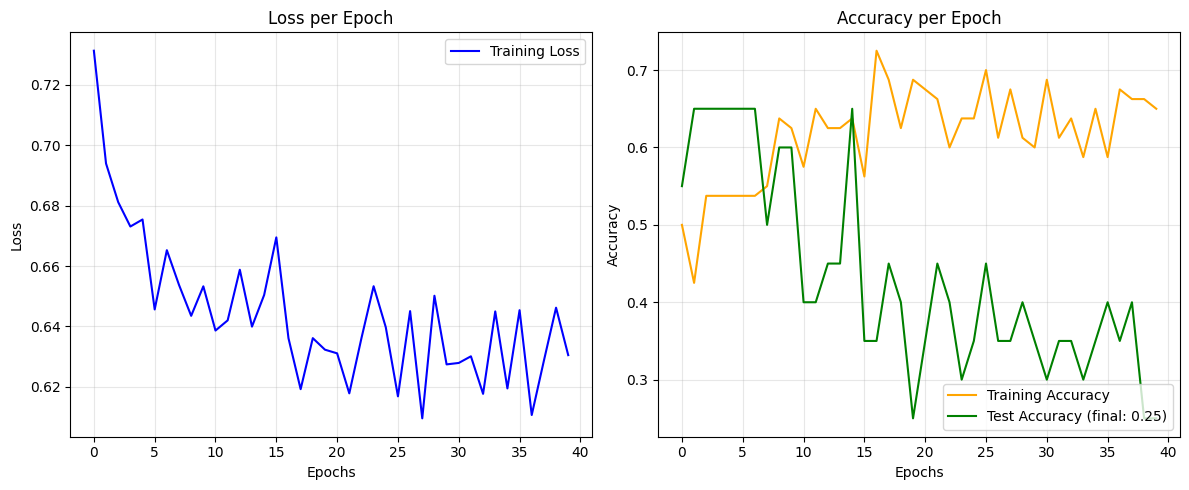

In [278]:
model                                       = GarbageCNN(input_shape=(1, 32, 32))
criterion                                   = nn.BCELoss()
optimizer                                   = optim.Adam(model.parameters(), lr=0.01,weight_decay=1e-3) # weight_decay=1e-3 = L2
model, loss_curve, train_curve, test_curve  = train_cnn_model(model,augmented_train_dataloader,augmented_test_dataloader,criterion,optimizer,num_epochs=40,device="cpu")

The dataset is still too small event with data augmentation

# CNN using TensorFlow

Check TF img format : 32, 32, 1 -> canal at the end

In [279]:
print("X_train_cnn :",X_train_cnn.shape)
print("X_test_cnn :", X_test_cnn.shape)

X_train_cnn : (80, 1, 32, 32)
X_test_cnn : (20, 1, 32, 32)


Permute data in order to be in the good format

In [280]:
X_train_cnn = np.transpose(X_train_cnn, (0, 2, 3, 1))
X_test_cnn  = np.transpose(X_test_cnn, (0, 2, 3, 1))
print("X_train_cnn :",X_train_cnn.shape)
print("X_test_cnn :", X_test_cnn.shape)


X_train_cnn : (80, 32, 32, 1)
X_test_cnn : (20, 32, 32, 1)


In [281]:
def model_tf(X_train_cnn,y_train_cnn,X_test_cnn,y_test_cnn,n_iter):

    # Define early stop to avoid overfitting and lr to avoird agressif LR
    early_stop = tf.keras.callbacks.EarlyStopping( monitor='val_loss', patience=10, restore_best_weights=True ) 
    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

    # Define model
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 1)),
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid',kernel_regularizer=tf.keras.regularizers.l2(0.001))])

    # Fit the model
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train_cnn, y_train_cnn,epochs=n_iter,validation_data=(X_test_cnn, y_test_cnn),callbacks=[early_stop, lr_schedule],verbose=0)

    # Test acc
    test_acc = history.history['val_accuracy'][-1]

    # Plot the Locc/acc 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['accuracy'], label='Training Accuracy',color='orange')
    axes[1].plot(history.history['val_accuracy'], label=f'Test Accuracy (final :{test_acc:.2f})',color ='green')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    plt.show()

    return history



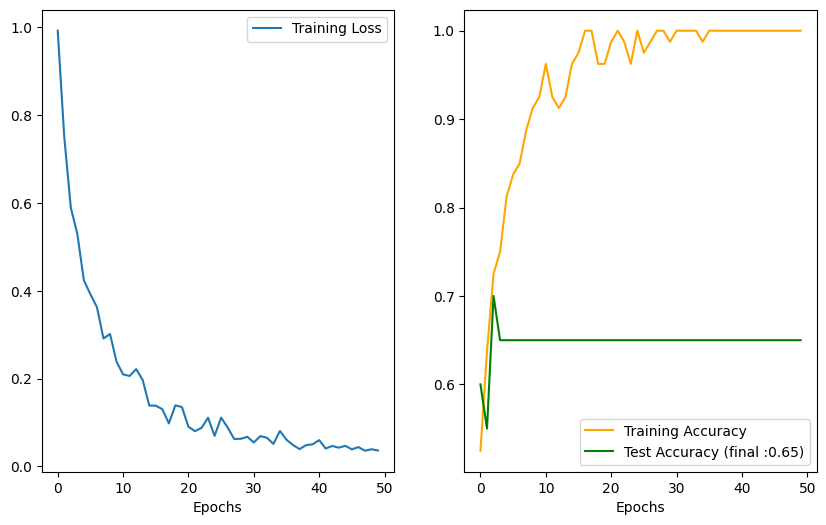

In [282]:
history = model_tf(X_train_cnn,y_train_cnn,X_test_cnn, y_test_cnn,n_iter=50)

In [283]:
def model_tf(X_train_cnn,y_train_cnn,X_test_cnn,y_test_cnn,n_iter):

    # Define early stop to avoid overfitting and lr to avoird agressif LR
    early_stop = tf.keras.callbacks.EarlyStopping( monitor='val_loss', patience=10, restore_best_weights=True ) 
    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

    # Define model
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 1)),
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation='sigmoid')])

    # Fit the model
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train_cnn, y_train_cnn,epochs=n_iter,validation_data=(X_test_cnn, y_test_cnn),callbacks=[early_stop, lr_schedule],verbose=0)

    # Test acc
    test_acc = history.history['val_accuracy'][-1]

    # Plot the Locc/acc 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['accuracy'], label='Training Accuracy',color='orange')
    axes[1].plot(history.history['val_accuracy'], label=f'Test Accuracy (final :{test_acc:.2f})',color ='green')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    plt.show()

    return history



Dropout and L2 penaly are useful

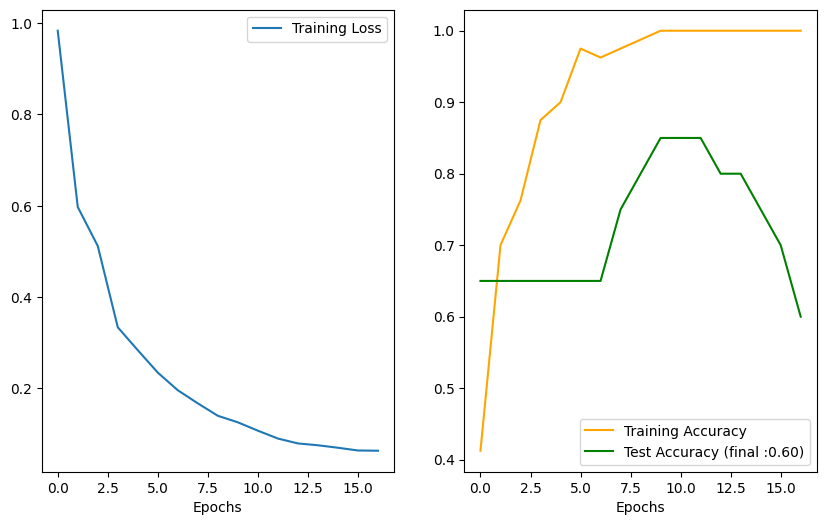

In [284]:
history = model_tf(X_train_cnn,y_train_cnn,X_test_cnn, y_test_cnn,n_iter=50)

# Overall conclusion

3 Neural networks were used on this small dataset!

The dataset is very small and overfitting was encounter!  TF seems to be the best model with an accuracy of 75% 
